In [619]:
!pip install pandas numpy statsmodels scikit-learn tensorflow seaborn flask

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [39]:
import pandas as pd

# Load the FAO SDG 2.1.1 dataset
df = pd.read_csv("FAO,DF_SDG_2_1_1,1.0+all.csv")

# Find unique areas
unique_areas = df['Area'].unique()
print("Unique Areas:")
for area in sorted(unique_areas):
    print(area)

Unique Areas:
Afghanistan
Africa
Albania
Algeria
Americas
Angola
Argentina
Armenia
Asia
Australia
Australia and New Zealand
Austria
Azerbaijan
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bolivia (Plurinational State of)
Bosnia and Herzegovina
Botswana
Brazil
Bulgaria
Burkina Faso
Cabo Verde
Cambodia
Cameroon
Canada
Caribbean
Central African Republic
Central America
Central Asia
Central Asia and Southern Asia
Chad
Chile
China
China, Hong Kong SAR
China, Macao SAR
Colombia
Comoros
Congo
Costa Rica
Croatia
Cuba
Cyprus
Czechia
Côte d'Ivoire
Democratic People's Republic of Korea
Democratic Republic of the Congo
Denmark
Djibouti
Dominica
Dominican Republic
Eastern Africa
Eastern Asia
Eastern Asia and South-eastern Asia
Eastern Europe
Ecuador
Egypt
El Salvador
Estonia
Eswatini
Ethiopia
Europe
Europe, Northern America, Australia and New Zealand
Fiji
Finland
France
French Polynesia
Gabon
Gambia
Georgia
Germany
Ghana
Greece
Guatemala
Guinea
Guinea-Bissau
Guyana
Haiti
High income countries
H

In [40]:
import pandas as pd

# Load the FAO SDG 2.1.1 dataset
df = pd.read_csv("FAO,DF_SDG_2_1_1,1.0+all.csv")

# Filter for target regions
target_regions = ["Central Asia", "Central America", "South America"]
df = df[df["Area"].isin(target_regions)]

# Keep only percentage-based data
df = df[df["UNIT_MEASURE"] == "PT"]

# Select and rename columns
df = df[["Area", "TIME_PERIOD", "OBS_VALUE"]]
df.columns = ["Region", "Year", "Undernourishment (%)"]

# Convert Year to integer
df["Year"] = df["Year"].astype(int)

# Clean Undernourishment (%) column
df['Undernourishment (%)'] = df['Undernourishment (%)'].replace('<', '', regex=True)
df['Undernourishment (%)'] = pd.to_numeric(df['Undernourishment (%)'], errors='coerce')

# Add lagged feature
df['Last_Year_Undernourishment'] = df.groupby('Region')['Undernourishment (%)'].shift(1)
df['Last_Year_Undernourishment'] = df.groupby('Region')['Last_Year_Undernourishment'].fillna(method='bfill')

# Train-Test Split (70-30: 2001-2016 train, 2017-2023 test)
train_end = 2016
test_start = 2017
test_end = 2023

region_data = {}
for region in target_regions:
    region_df = df[df['Region'] == region].copy()
    train_data = region_df[region_df['Year'] <= train_end]
    test_data = region_df[(region_df['Year'] >= test_start) & (region_df['Year'] <= test_end)]
    region_data[region] = {
        'full_data': region_df,
        'train': train_data,
        'test': test_data
    }

# Verify
for region, data in region_data.items():
    print(f"\n{region} Training Data (2001-2016):")
    print(data['train'])
    print(f"\n{region} Test Data (2017-2023):")
    print(data['test'])

# Optional: Print data availability details
for region in target_regions:
    print(f"\n{region} Data Availability:")
    print(f"Total years of data: {region_data[region]['full_data']['Year'].nunique()}")
    print(f"Year range: {region_data[region]['full_data']['Year'].min()} - {region_data[region]['full_data']['Year'].max()}")


Central Asia Training Data (2001-2016):
            Region  Year  Undernourishment (%)  Last_Year_Undernourishment
9651  Central Asia  2000                  14.5                        14.5
9652  Central Asia  2001                  16.6                        14.5
9653  Central Asia  2002                  17.3                        16.6
9654  Central Asia  2003                  16.1                        17.3
9655  Central Asia  2004                  15.7                        16.1
9656  Central Asia  2005                  13.8                        15.7
9657  Central Asia  2006                  12.0                        13.8
9658  Central Asia  2007                   9.9                        12.0
9659  Central Asia  2008                   8.6                         9.9
9660  Central Asia  2009                   7.4                         8.6
9661  Central Asia  2010                   6.4                         7.4
9662  Central Asia  2011                   5.6             

C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\524765819.py:26: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df['Last_Year_Undernourishment'] = df.groupby('Region')['Last_Year_Undernourishment'].fillna(method='bfill')
C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\524765819.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Last_Year_Undernourishment'] = df.groupby('Region')['Last_Year_Undernourishment'].fillna(method='bfill')


In [20]:
# ARIMA Model for Central Asia
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select Central Asia's data
central_asia_train = region_data['Central Asia']['train']
central_asia_test = region_data['Central Asia']['test']

# Prepare data for ARIMA
central_asia_train['Undernourishment (%)'] = central_asia_train['Undernourishment (%)'].astype(float)
central_asia_test['Undernourishment (%)'] = central_asia_test['Undernourishment (%)'].astype(float)

# Try different ARIMA orders
orders = [(1,1,1), (1,1,2), (2,1,1), (2,1,2), (0,1,1)]
best_aic = float('inf')
best_order = None
best_model = None

# Find best model using AIC
for order in orders:
    try:
        # Fit model with each order
        temp_model = ARIMA(central_asia_train['Undernourishment (%)'], order=order)
        temp_model_fit = temp_model.fit()
        
        # Save if it has better AIC
        if temp_model_fit.aic < best_aic:
            best_aic = temp_model_fit.aic
            best_order = order
            best_model = temp_model_fit
        
        print(f"ARIMA{order} AIC: {temp_model_fit.aic:.3f}")
    except Exception as e:
        print(f"ARIMA{order} failed to converge: {e}")

print(f"\nBest model: ARIMA{best_order} with AIC: {best_aic:.3f}")

C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\3579526398.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_asia_train['Undernourishment (%)'] = central_asia_train['Undernourishment (%)'].astype(float)
C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\3579526398.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_asia_test['Undernourishment (%)'] = central_asia_test['Undernourishment (%)'].astype(float)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: 

ARIMA(1, 1, 1) AIC: 43.653
ARIMA(1, 1, 2) AIC: 44.766
ARIMA(2, 1, 1) AIC: 45.588
ARIMA(2, 1, 2) AIC: 46.901


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self.

ARIMA(0, 1, 1) AIC: 47.565

Best model: ARIMA(1, 1, 1) with AIC: 43.653


In [21]:
# Forecast and Evaluation
def evaluate_arima_model(best_model, train_data, test_data):
    if best_model is None:
        print("No model available for evaluation")
        return None
    try:
        # Forecast 10 years ahead
        forecast_steps = len(test_data) + 2  # Test period + 2 more years
        forecast = best_model.forecast(steps=forecast_steps)

        # Create forecasting DataFrame
        central_asia_arima_forecast = pd.DataFrame({
            "Year": list(range(test_data['Year'].min(), test_data['Year'].max() + 3)),
            "ARIMA": forecast
        })

        # Evaluate only on available test data
        test_eval = test_data.copy()
        test_eval = test_eval[(test_eval["Year"] >= 2017) & (test_eval["Year"] <= 2023)]

        # Get ARIMA predictions for the same years
        forecast_subset = central_asia_arima_forecast[
            central_asia_arima_forecast["Year"].between(2017, 2023)
        ]
        test_eval["ARIMA"] = forecast_subset["ARIMA"].values

        # Calculate metrics
        # Remove NaN values
        test_eval_clean = test_eval.dropna(subset=['Undernourishment (%)', 'ARIMA'])
        
        y_true = test_eval_clean['Undernourishment (%)']
        y_pred = test_eval_clean['ARIMA']

        # Calculate metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        
        # R-squared calculation with robust handling
        y_mean = np.mean(y_true)
        ss_tot = np.sum((y_true - y_mean)**2)
        ss_res = np.sum((y_true - y_pred)**2)
        
        try:
            r2 = 1 - (ss_res / ss_tot)
        except ZeroDivisionError:
            r2 = np.nan

        print("\nCentral Asia - ARIMA Evaluation Metrics")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")

        return central_asia_arima_forecast
    except Exception as e:
        print(f"Error in model evaluation: {e}")
        return None

# Evaluate the model
if best_model is not None:
    central_asia_arima_forecast = evaluate_arima_model(best_model, central_asia_train, central_asia_test)
else:
    print("Could not evaluate model due to training failure")


Central Asia - ARIMA Evaluation Metrics
MAE: 0.2296
RMSE: 0.3465
R²: -1.1157


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [23]:
# ARIMA Model for Central America
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select Central America's data
central_america_train = region_data['Central America']['train']
central_america_test = region_data['Central America']['test']

# Prepare data for ARIMA
central_america_train['Undernourishment (%)'] = central_america_train['Undernourishment (%)'].astype(float)
central_america_test['Undernourishment (%)'] = central_america_test['Undernourishment (%)'].astype(float)

# Try different ARIMA orders
orders = [(1,1,1), (1,1,2), (2,1,1), (2,1,2), (0,1,1)]
best_aic = float('inf')
best_order = None
best_model = None

# Find best model using AIC
for order in orders:
    try:
        # Fit model with each order
        temp_model = ARIMA(central_america_train['Undernourishment (%)'], order=order)
        temp_model_fit = temp_model.fit()
        
        # Save if it has better AIC
        if temp_model_fit.aic < best_aic:
            best_aic = temp_model_fit.aic
            best_order = order
            best_model = temp_model_fit
        
        print(f"ARIMA{order} AIC: {temp_model_fit.aic:.3f}")
    except Exception as e:
        print(f"ARIMA{order} failed to converge: {e}")

print(f"\nBest model: ARIMA{best_order} with AIC: {best_aic:.3f}")

C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\2974634268.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_america_train['Undernourishment (%)'] = central_america_train['Undernourishment (%)'].astype(float)
C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\2974634268.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_america_test['Undernourishment (%)'] = central_america_test['Undernourishment (%)'].astype(float)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_mo

ARIMA(1, 1, 1) AIC: 28.559
ARIMA(1, 1, 2) AIC: 26.543
ARIMA(2, 1, 1) AIC: 21.262


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(2, 1, 2) AIC: 19.033
ARIMA(0, 1, 1) AIC: 25.425

Best model: ARIMA(2, 1, 2) with AIC: 19.033


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [24]:
# Forecast and Evaluation
def evaluate_arima_model(best_model, train_data, test_data):
    if best_model is None:
        print("No model available for evaluation")
        return None
    try:
        # Forecast 10 years ahead
        forecast_steps = len(test_data) + 2  # Test period + 2 more years
        forecast = best_model.forecast(steps=forecast_steps)

        # Create forecasting DataFrame
        central_america_arima_forecast = pd.DataFrame({
            "Year": list(range(test_data['Year'].min(), test_data['Year'].max() + 3)),
            "ARIMA": forecast
        })

        # Evaluate only on available test data
        test_eval = test_data.copy()
        test_eval = test_eval[(test_eval["Year"] >= 2017) & (test_eval["Year"] <= 2023)]

        # Get ARIMA predictions for the same years
        forecast_subset = central_america_arima_forecast[
            central_america_arima_forecast["Year"].between(2017, 2023)
        ]
        test_eval["ARIMA"] = forecast_subset["ARIMA"].values

        # Calculate metrics
        # Remove NaN values
        test_eval_clean = test_eval.dropna(subset=['Undernourishment (%)', 'ARIMA'])
        
        y_true = test_eval_clean['Undernourishment (%)']
        y_pred = test_eval_clean['ARIMA']

        # Calculate metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        
        # R-squared calculation with robust handling
        y_mean = np.mean(y_true)
        ss_tot = np.sum((y_true - y_mean)**2)
        ss_res = np.sum((y_true - y_pred)**2)
        
        try:
            r2 = 1 - (ss_res / ss_tot)
        except ZeroDivisionError:
            r2 = np.nan

        print("\nCentral America - ARIMA Evaluation Metrics")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")

        return central_america_arima_forecast
    except Exception as e:
        print(f"Error in model evaluation: {e}")
        return None

# Evaluate the model
if best_model is not None:
    central_america_arima_forecast = evaluate_arima_model(best_model, central_america_train, central_america_test)
else:
    print("Could not evaluate model due to training failure")


Central America - ARIMA Evaluation Metrics
MAE: 0.5277
RMSE: 0.6165
R²: -14.7815


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [4]:
# ARIMA Model for South America
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select South America's data
south_america_train = region_data['South America']['train']
south_america_test = region_data['South America']['test']

# Prepare data for ARIMA
south_america_train['Undernourishment (%)'] = south_america_train['Undernourishment (%)'].astype(float)
south_america_test['Undernourishment (%)'] = south_america_test['Undernourishment (%)'].astype(float)

# Try different ARIMA orders
orders = [(1,1,1), (1,1,2), (2,1,1), (2,1,2), (0,1,1)]
best_aic = float('inf')
best_order = None
best_model = None

# Find best model using AIC
for order in orders:
    try:
        # Fit model with each order
        temp_model = ARIMA(south_america_train['Undernourishment (%)'], order=order)
        temp_model_fit = temp_model.fit()
        
        # Save if it has better AIC
        if temp_model_fit.aic < best_aic:
            best_aic = temp_model_fit.aic
            best_order = order
            best_model = temp_model_fit
        
        print(f"ARIMA{order} AIC: {temp_model_fit.aic:.3f}")
    except Exception as e:
        print(f"ARIMA{order} failed to converge: {e}")

print(f"\nBest model: ARIMA{best_order} with AIC: {best_aic:.3f}")

C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\2134035640.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  south_america_train['Undernourishment (%)'] = south_america_train['Undernourishment (%)'].astype(float)
C:\Users\shahe\AppData\Local\Temp\ipykernel_20048\2134035640.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  south_america_test['Undernourishment (%)'] = south_america_test['Undernourishment (%)'].astype(float)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:4

ARIMA(1, 1, 1) AIC: 42.215


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(1, 1, 2) AIC: 41.821
ARIMA(2, 1, 1) AIC: 43.312


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self.

ARIMA(2, 1, 2) AIC: 44.017
ARIMA(0, 1, 1) AIC: 41.854

Best model: ARIMA(1, 1, 2) with AIC: 41.821


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [5]:
# Forecast and Evaluation
def evaluate_arima_model(best_model, train_data, test_data):
    if best_model is None:
        print("No model available for evaluation")
        return None
    try:
        # Forecast 10 years ahead
        forecast_steps = len(test_data) + 2  # Test period + 2 more years
        forecast = best_model.forecast(steps=forecast_steps)

        # Create forecasting DataFrame
        south_america_arima_forecast = pd.DataFrame({
            "Year": list(range(test_data['Year'].min(), test_data['Year'].max() + 3)),
            "ARIMA": forecast
        })

        # Evaluate only on available test data
        test_eval = test_data.copy()
        test_eval = test_eval[(test_eval["Year"] >= 2017) & (test_eval["Year"] <= 2023)]

        # Get ARIMA predictions for the same years
        forecast_subset = south_america_arima_forecast[
            south_america_arima_forecast["Year"].between(2017, 2023)
        ]
        test_eval["ARIMA"] = forecast_subset["ARIMA"].values

        # Calculate metrics
        # Remove NaN values
        test_eval_clean = test_eval.dropna(subset=['Undernourishment (%)', 'ARIMA'])
        
        y_true = test_eval_clean['Undernourishment (%)']
        y_pred = test_eval_clean['ARIMA']

        # Calculate metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred, squared=False)
        
        # R-squared calculation with robust handling
        y_mean = np.mean(y_true)
        ss_tot = np.sum((y_true - y_mean)**2)
        ss_res = np.sum((y_true - y_pred)**2)
        
        try:
            r2 = 1 - (ss_res / ss_tot)
        except ZeroDivisionError:
            r2 = np.nan

        print("\nSouth America - ARIMA Evaluation Metrics")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")

        return south_america_arima_forecast
    except Exception as e:
        print(f"Error in model evaluation: {e}")
        return None

# Evaluate the model
if best_model is not None:
    south_america_arima_forecast = evaluate_arima_model(best_model, south_america_train, south_america_test)
else:
    print("Could not evaluate model due to training failure")


South America - ARIMA Evaluation Metrics
MAE: 1.2780
RMSE: 1.4858
R²: -5.1885


C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\shahe\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [6]:
# Random Forest for Central Asia
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare training data
train = region_data['Central Asia']['train'].copy()
train['Undernourishment (%)'] = train['Undernourishment (%)'].astype(float)
train['Year'] = train['Year'].astype(int)

# Create lag features (previous years' values)
for i in range(1, 4):
    train[f'Lag{i}'] = train['Undernourishment (%)'].shift(i)

# Drop rows with missing lagged values
train = train.dropna()

# Add year-related features
train['Years_Since_2000'] = train['Year'] - 2000  # Normalise year

# Train test split
X_train = train[['Lag1', 'Lag2', 'Lag3', 'Years_Since_2000']]
y_train = train['Undernourishment (%)']

# Train the model with some tuning
model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Increased depth to capture more complexity
    min_samples_split=2,   # Default value
    random_state=42        # For reproducibility
)
model.fit(X_train, y_train)

# Show feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("Feature importance:")
print(feature_importance)

# Forecast step by step from 2016 to 2025
last_known_vals = train[['Lag1', 'Lag2', 'Lag3']].iloc[-1].values[::-1]
last_year = train['Year'].max()
preds = []

for step in range(10):  # 2016–2025
    current_year = last_year + 1
    years_since_2000 = current_year - 2000
    
    # Prepare input features for prediction
    input_features = np.append(last_known_vals[-3:], years_since_2000).reshape(1, -1)
    
    # Make prediction
    pred = model.predict(input_features)[0]
    preds.append(pred)
    
    # Update lag values for next step
    last_known_vals = np.roll(last_known_vals, -1)
    last_known_vals[-1] = pred
    last_year += 1

# Store forecasts
central_asia_rf_forecast = pd.DataFrame({
    'Year': list(range(2016, 2026)),
    'RF': preds
})

Feature importance:
            Feature  Importance
3  Years_Since_2000    0.376316
1              Lag2    0.249466
0              Lag1    0.198346
2              Lag3    0.175873


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: U

In [7]:
# Evaluate on test data (2017-2023)
test_eval = region_data['Central Asia']['test'].copy()
test_eval = test_eval[(test_eval['Year'] >= 2017) & (test_eval['Year'] <= 2023)].reset_index(drop=True)

# Merge predictions with test data
test_eval = test_eval.merge(central_asia_rf_forecast, on='Year', how='left')
test_eval['Undernourishment (%)'] = test_eval['Undernourishment (%)'].astype(float)

# Filter out missing values
eval_df = test_eval.dropna(subset=['Undernourishment (%)', 'RF'])

# Calculate metrics
y_true = eval_df['Undernourishment (%)']
y_pred = eval_df['RF']

# Calculate simple baseline (mean of training data)
baseline_pred = train['Undernourishment (%)'].mean()
baseline_mae = mean_absolute_error(y_true, [baseline_pred] * len(y_true))
baseline_rmse = np.sqrt(mean_squared_error(y_true, [baseline_pred] * len(y_true)))

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

# R-squared calculation with robust handling
y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean)**2)
ss_res = np.sum((y_true - y_pred)**2)

try:
    r2 = 1 - (ss_res / ss_tot)
except ZeroDivisionError:
    r2 = np.nan

print("Central Asia - RF Evaluation Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Predicted values range: {min(y_pred):.2f} to {max(y_pred):.2f}")

Central Asia - RF Evaluation Metrics
MAE: 0.7766
RMSE: 0.8108
R²: -10.5861
Predicted values range: 3.83 to 3.86


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [8]:
# Random Forest for Central America
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare training data
train = region_data['Central America']['train'].copy()
train['Undernourishment (%)'] = train['Undernourishment (%)'].astype(float)
train['Year'] = train['Year'].astype(int)

# Create lag features (previous years' values)
for i in range(1, 4):
    train[f'Lag{i}'] = train['Undernourishment (%)'].shift(i)

# Drop rows with missing lagged values
train = train.dropna()

# Add year-related features
train['Years_Since_2000'] = train['Year'] - 2000  # Normalise year

# Train test split
X_train = train[['Lag1', 'Lag2', 'Lag3', 'Years_Since_2000']]
y_train = train['Undernourishment (%)']

# Train the model with some tuning
model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Increased depth to capture more complexity
    min_samples_split=2,   # Default value
    random_state=42        # For reproducibility
)
model.fit(X_train, y_train)

# Show feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("Feature importance:")
print(feature_importance)

# Forecast step by step from 2016 to 2025
last_known_vals = train[['Lag1', 'Lag2', 'Lag3']].iloc[-1].values[::-1]
last_year = train['Year'].max()
preds = []

for step in range(10):  # 2016–2025
    current_year = last_year + 1
    years_since_2000 = current_year - 2000
    
    # Prepare input features for prediction
    input_features = np.append(last_known_vals[-3:], years_since_2000).reshape(1, -1)
    
    # Make prediction
    pred = model.predict(input_features)[0]
    preds.append(pred)
    
    # Update lag values for next step
    last_known_vals = np.roll(last_known_vals, -1)
    last_known_vals[-1] = pred
    last_year += 1

# Store forecasts
central_america_rf_forecast = pd.DataFrame({
    'Year': list(range(2016, 2026)),
    'RF': preds
})

Feature importance:
            Feature  Importance
3  Years_Since_2000    0.658694
0              Lag1    0.211546
1              Lag2    0.092611
2              Lag3    0.037149


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: U

In [9]:
# Evaluate on test data (2017-2023)
test_eval = region_data['Central America']['test'].copy()
test_eval = test_eval[(test_eval['Year'] >= 2017) & (test_eval['Year'] <= 2023)].reset_index(drop=True)

# Merge predictions with test data
test_eval = test_eval.merge(central_america_rf_forecast, on='Year', how='left')
test_eval['Undernourishment (%)'] = test_eval['Undernourishment (%)'].astype(float)

# Filter out missing values
eval_df = test_eval.dropna(subset=['Undernourishment (%)', 'RF'])

# Calculate metrics
y_true = eval_df['Undernourishment (%)']
y_pred = eval_df['RF']

# Calculate simple baseline (mean of training data)
baseline_pred = train['Undernourishment (%)'].mean()
baseline_mae = mean_absolute_error(y_true, [baseline_pred] * len(y_true))
baseline_rmse = np.sqrt(mean_squared_error(y_true, [baseline_pred] * len(y_true)))

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

# R-squared calculation with robust handling
y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean)**2)
ss_res = np.sum((y_true - y_pred)**2)

try:
    r2 = 1 - (ss_res / ss_tot)
except ZeroDivisionError:
    r2 = np.nan

print("Central America - RF Evaluation Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Predicted values range: {min(y_pred):.2f} to {max(y_pred):.2f}")

Central America - RF Evaluation Metrics
MAE: 0.4084
RMSE: 0.4375
R²: -6.9472
Predicted values range: 6.22 to 6.22


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [10]:
# Random Forest for South America
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Prepare training data
train = region_data['South America']['train'].copy()

# Clean and convert data to numeric
train['Undernourishment (%)'] = train['Undernourishment (%)'].astype(float)
train['Year'] = train['Year'].astype(int)

# Create lag features (previous years' values)
for i in range(1, 4):
    train[f'Lag{i}'] = train['Undernourishment (%)'].shift(i)

# Drop rows with missing lagged values
train = train.dropna()

# Add year-related features
train['Years_Since_2000'] = train['Year'] - 2000  # Normalise year

# Train test split
X_train = train[['Lag1', 'Lag2', 'Lag3', 'Years_Since_2000']]
y_train = train['Undernourishment (%)']

# Train the model with some tuning
model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Increased depth to capture more complexity
    min_samples_split=2,   # Default value
    random_state=42        # For reproducibility
)
model.fit(X_train, y_train)

# Show feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("Feature importance:")
print(feature_importance)

# Forecast step by step from 2016 to 2025
last_known_vals = train[['Lag1', 'Lag2', 'Lag3']].iloc[-1].values[::-1]
last_year = train['Year'].max()
preds = []

for step in range(10):  # 2016–2025
    current_year = last_year + 1
    years_since_2000 = current_year - 2000
    
    # Prepare input features for prediction
    input_features = np.append(last_known_vals[-3:], years_since_2000).reshape(1, -1)
    
    # Make prediction
    pred = model.predict(input_features)[0]
    preds.append(pred)
    
    # Update lag values for next step
    last_known_vals = np.roll(last_known_vals, -1)
    last_known_vals[-1] = pred
    last_year += 1

# Store forecasts
south_america_rf_forecast = pd.DataFrame({
    'Year': list(range(2016, 2026)),
    'RF': preds
})

Feature importance:
            Feature  Importance
3  Years_Since_2000    0.364662
0              Lag1    0.229807
1              Lag2    0.220663
2              Lag3    0.184868


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\base.py:493: U

In [11]:
# Evaluate on test data (2017-2023)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_eval = region_data['South America']['test'].copy()
test_eval['Undernourishment (%)'] = test_eval['Undernourishment (%)'].astype(float)
test_eval = test_eval[(test_eval['Year'] >= 2017) & (test_eval['Year'] <= 2023)].reset_index(drop=True)

# Merge predictions with test data
test_eval = test_eval.merge(south_america_rf_forecast, on='Year', how='left')
test_eval['Undernourishment (%)'] = test_eval['Undernourishment (%)'].astype(float)

# Filter out missing values
eval_df = test_eval.dropna(subset=['Undernourishment (%)', 'RF'])

# Calculate metrics
y_true = eval_df['Undernourishment (%)']
y_pred = eval_df['RF']

# Calculate simple baseline (mean of training data)
baseline_pred = train['Undernourishment (%)'].mean()
baseline_mae = mean_absolute_error(y_true, [baseline_pred] * len(y_true))
baseline_rmse = np.sqrt(mean_squared_error(y_true, [baseline_pred] * len(y_true)))

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

# R-squared calculation with robust handling
y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean)**2)
ss_res = np.sum((y_true - y_pred)**2)

try:
    r2 = 1 - (ss_res / ss_tot)
except ZeroDivisionError:
    r2 = np.nan

print("South America - RF Evaluation Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Predicted values range: {min(y_pred):.2f} to {max(y_pred):.2f}")

South America - RF Evaluation Metrics
MAE: 1.0901
RMSE: 1.2511
R²: -3.3878
Predicted values range: 4.32 to 4.42


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [12]:
# LSTM model for Central Asia
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import pandas as pd

# Prepare data
train = region_data['Central Asia']['train'].copy()
test = region_data['Central Asia']['test'].copy()
train["Undernourishment (%)"] = train["Undernourishment (%)"].astype(float)

# More sophisticated feature preparation
def create_sequences(data, look_back=5):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Scale data with more robust scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train[["Undernourishment (%)"]])

# Create sequences with longer look-back
look_back = 5
X, y = create_sequences(scaled_train, look_back)
print(f"Training data shape: X={X.shape}, y={y.shape}")

# More complex LSTM architecture
model = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(64, activation='relu', return_sequences=True),  # Increased units
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32, activation='relu'),  # Second layer with fewer units
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),  # Added dense layer for additional complexity
    Dense(1)
])

# Compile model with adaptive learning rate
model.compile(optimizer='adam', loss='mse')
model.summary()

# Advanced callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,  # More patience
    restore_best_weights=True,
    min_delta=0.0001  # Smaller improvement threshold
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce learning rate
    patience=15,
    min_lr=0.00001
)

# Train model with more sophisticated approach
history = model.fit(
    X, y,
    epochs=300,  # More epochs with early stopping
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# Print training stats
print(f"Training stopped after {len(history.history['loss'])} epochs")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

# Forecast for 2016–2025 (10 years)
last_sequence = scaled_train[-look_back:].reshape(1, look_back, 1)
preds = []

for year in range(10):
    # Predict next value
    pred_scaled = model.predict(last_sequence, verbose=0)[0][0]
    preds.append(pred_scaled)
    
    # Update sequence for next prediction
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, 0] = pred_scaled

# Inverse transform to original scale
preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

# Store predictions
central_asia_lstm_forecast = pd.DataFrame({
    "Year": list(range(2016, 2026)),
    "LSTM": preds
})

Training data shape: X=(12, 5, 1), y=(12, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 5, 64)               │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 5, 64)               │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,241 (118.13 KB)

 Trainable params: 30,049 (117.38 KB)

 Non-trainable params: 192 (768.00 B)

Training stopped after 64 epochs
Final training loss: 0.215615
Final validation loss: 0.000378


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare test data for evaluation
eval_df = region_data['Central Asia']['test'].copy()
eval_df = eval_df[(eval_df['Year'] >= 2017) & (eval_df['Year'] <= 2023)].reset_index(drop=True)

# Add LSTM predictions
forecast_subset = central_asia_lstm_forecast[central_asia_lstm_forecast['Year'].between(2017, 2023)]
eval_df['LSTM'] = forecast_subset['LSTM'].values

# Clean data by removing NaN values
eval_df_clean = eval_df.dropna(subset=['Undernourishment (%)', 'LSTM'])

# Calculate evaluation metrics
y_true = eval_df_clean['Undernourishment (%)']
y_pred = eval_df_clean['LSTM']

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

# R-squared calculation with robust handling
y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean)**2)
ss_res = np.sum((y_true - y_pred)**2)

try:
    r2 = 1 - (ss_res / ss_tot)
except ZeroDivisionError:
    r2 = np.nan

# Print metrics
print("Central Asia - LSTM Evaluation Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Create comparison table
comparison = pd.DataFrame({
    'Year': eval_df_clean['Year'],
    'Actual': y_true,
    'LSTM': y_pred,
    'Error': y_true - y_pred
})
print("\nPrediction vs Actual:")
print(comparison)

Central Asia - LSTM Evaluation Metrics
MAE: 0.8343
RMSE: 0.8678
R²: -12.2736

Prediction vs Actual:
   Year  Actual      LSTM     Error
0  2017     3.4  3.888026 -0.488026
1  2018     2.9  3.891016 -0.991016
2  2019     2.6  3.892179 -1.292179
3  2020     3.2  3.892282 -0.692282
4  2021     3.2  3.892107 -0.692107
5  2022     3.1  3.892094 -0.792094
6  2023     3.0  3.892086 -0.892086


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
# LSTM model for Central America
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import pandas as pd

# Prepare training data
train = region_data['Central America']['train'].copy()
test = region_data['Central America']['test'].copy()
train["Undernourishment (%)"] = train["Undernourishment (%)"].astype(float)

# Check data distribution before scaling
print(f"Central America training data stats:")
print(f"Min: {train['Undernourishment (%)'].min():.2f}, Max: {train['Undernourishment (%)'].max():.2f}")
print(f"Mean: {train['Undernourishment (%)'].mean():.2f}, Std: {train['Undernourishment (%)'].std():.2f}")

# Scale data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train[["Undernourishment (%)"]])

# Create sequences
look_back = 3
X, y = [], []
for i in range(look_back, len(scaled_train)):
    X.append(scaled_train[i - look_back:i])
    y.append(scaled_train[i])
X = np.array(X)
y = np.array(y)

# Build model with slightly adjusted architecture
model = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(64, activation='relu', return_sequences=True),  # Slightly larger first layer
    Dropout(0.2),
    LSTM(32, activation='relu'),  # Smaller second layer
    Dropout(0.1),  # Additional dropout
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.0001
)

# Train model with callbacks
history = model.fit(
    X, y,
    epochs=200,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# Report training details
print(f"Model trained for {len(history.history['loss'])} epochs")
print(f"Final loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

# Forecast 2016–2025
last_sequence = scaled_train[-look_back:].reshape(1, look_back, 1)
preds = []

for year in range(10):
    # Make prediction
    pred_scaled = model.predict(last_sequence, verbose=0)[0][0]
    preds.append(pred_scaled)
    
    # Update sequence for next prediction
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, 0] = pred_scaled

# Inverse transform predictions to original scale
preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

# Store forecasts
central_america_lstm_forecast = pd.DataFrame({
    "Year": list(range(2016, 2026)),
    "LSTM": preds
})

# Print forecast range
print(f"Forecast range: {min(preds):.2f} to {max(preds):.2f}")

Central America training data stats:
Min: 6.00, Max: 8.20
Mean: 6.93, Std: 0.63
Model trained for 48 epochs
Final loss: 0.096751
Final validation loss: 0.030320
Forecast range: 6.26 to 6.29


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare test data (2017-2023)
eval_df = region_data['Central America']['test'].copy()
eval_df = eval_df[(eval_df['Year'] >= 2017) & (eval_df['Year'] <= 2023)].reset_index(drop=True)

# Merge with predictions
forecast_subset = central_america_lstm_forecast[central_america_lstm_forecast['Year'].between(2017, 2023)]
eval_df['LSTM'] = forecast_subset['LSTM'].values

# Clean data by removing NaN values
eval_df_clean = eval_df.dropna(subset=['Undernourishment (%)', 'LSTM'])

# Calculate metrics
y_true = eval_df_clean['Undernourishment (%)']
y_pred = eval_df_clean['LSTM']

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

# R-squared calculation with robust handling
y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean)**2)
ss_res = np.sum((y_true - y_pred)**2)

try:
    r2 = 1 - (ss_res / ss_tot)
except ZeroDivisionError:
    r2 = np.nan

# Print metrics
print("Central America - LSTM Evaluation Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Print detailed comparison
results = pd.DataFrame({
    'Year': eval_df_clean['Year'],
    'Actual': y_true,
    'Predicted': y_pred,
    'Error': y_true - y_pred
})
print("\nYear-by-year comparison:")
print(results)

Central America - LSTM Evaluation Metrics
MAE: 0.4581
RMSE: 0.4847
R²: -8.7543

Year-by-year comparison:
   Year  Actual  Predicted     Error
0  2017     6.0   6.270936 -0.270936
1  2018     6.0   6.261514 -0.261514
2  2019     5.6   6.275243 -0.675243
3  2020     5.6   6.274449 -0.674449
4  2021     5.8   6.274497 -0.474497
5  2022     5.9   6.275172 -0.375172
6  2023     5.8   6.275149 -0.475149


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [16]:
# LSTM model for South America
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd

# Prepare training data
train = region_data['South America']['train'].copy()

# Clean and convert data to numeric
train['Undernourishment (%)'] = train['Undernourishment (%)'].astype(float)

# Print data characteristics
print("South America training data:")
print(f"Rows: {len(train)}")
print(f"Min value: {train['Undernourishment (%)'].min():.2f}")
print(f"Max value: {train['Undernourishment (%)'].max():.2f}")
print(f"Mean value: {train['Undernourishment (%)'].mean():.2f}")

# Scale data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train[["Undernourishment (%)"]])

# Create sequences with lookback
look_back = 3
X, y = [], []
for i in range(look_back, len(scaled_train)):
    X.append(scaled_train[i - look_back:i])
    y.append(scaled_train[i])
X = np.array(X)
y = np.array(y)

# Note data size
print(f"Training samples: {X.shape[0]}")

# Build model 
model = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(32, activation='relu', return_sequences=True),  # Network for dataset
    Dropout(0.1),  # Lower dropout
    LSTM(16, activation='relu'),  # Second layer
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train with early stopping 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,  # More patience for dataset
    restore_best_weights=True,
    verbose=1  # Show stopping info
)

# Train model
history = model.fit(
    X, y,
    epochs=200,
    validation_split=0.2,  # 20% validation
    callbacks=[early_stop],
    verbose=0
)

# Forecast 10 years (2016–2025)
last_sequence = scaled_train[-look_back:].reshape(1, look_back, 1)
preds = []

for _ in range(10):
    # Predict next value
    pred_scaled = model.predict(last_sequence, verbose=0)[0][0]
    preds.append(pred_scaled)
    
    # Update sequence for next prediction
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, 0] = pred_scaled

# Inverse transform to original scale
preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

# Ensure no prediction is below minimum observed value
min_val = train["Undernourishment (%)"].min()
preds = np.maximum(preds, min_val)

# Store forecasts
south_america_lstm_forecast = pd.DataFrame({
    "Year": list(range(2016, 2026)),
    "LSTM": preds
})

# Print forecast range
print(f"Forecast range: {min(preds):.2f} to {max(preds):.2f}")

South America training data:
Rows: 17
Min value: 3.60
Max value: 11.10
Mean value: 6.94
Training samples: 14
Epoch 61: early stopping
Restoring model weights from the end of the best epoch: 31.
Forecast range: 4.26 to 4.28


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare test data for evaluation
eval_df = region_data['South America']['test'].copy()

# Clean and convert data to numeric
eval_df['Undernourishment (%)'] = eval_df['Undernourishment (%)'].astype(float)
eval_df = eval_df[(eval_df['Year'] >= 2017) & (eval_df['Year'] <= 2023)].reset_index(drop=True)

# Add LSTM predictions
forecast_subset = south_america_lstm_forecast[south_america_lstm_forecast['Year'].between(2017, 2023)]
eval_df['LSTM'] = forecast_subset['LSTM'].values

# Clean data by removing NaN values
eval_df_clean = eval_df.dropna(subset=['Undernourishment (%)', 'LSTM'])

# Calculate metrics
y_true = eval_df_clean['Undernourishment (%)']
y_pred = eval_df_clean['LSTM']

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

# R-squared calculation with robust handling
y_mean = np.mean(y_true)
ss_tot = np.sum((y_true - y_mean)**2)
ss_res = np.sum((y_true - y_pred)**2)

try:
    r2 = 1 - (ss_res / ss_tot)
except ZeroDivisionError:
    r2 = np.nan

# Print metrics
print("South America - LSTM Evaluation Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Print detailed comparison
results = pd.DataFrame({
    'Year': eval_df_clean['Year'],
    'Actual': y_true,
    'Predicted': y_pred,
    'Error': y_true - y_pred
})
print("\nYear-by-year comparison:")
print(results)

South America - LSTM Evaluation Metrics
MAE: 1.1911
RMSE: 1.3338
R²: -3.9869

Year-by-year comparison:
   Year  Actual  Predicted     Error
0  2017     4.9   4.270734  0.629266
1  2018     5.0   4.279263  0.720737
2  2019     4.8   4.262427  0.537573
3  2020     5.9   4.262649  1.637351
4  2021     6.5   4.262548  2.237452
5  2022     5.9   4.262267  1.637733
6  2023     5.2   4.262266  0.937734


C:\Users\shahe\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [18]:
import pandas as pd

# Evaluation Table with updated metrics from new code runs
evaluation_data = [
    # Central Asia
    ["Central Asia", "ARIMA", 0.2296, 0.3465, -1.1157],
    ["Central Asia", "RF", 0.7766, 0.8108, -10.5861],
    ["Central Asia", "LSTM", 0.8343, 0.8678, -12.2736],
    ["Central Asia", "SARIMA", 0.3370, 0.3615, -1.3038],
    ["Central Asia", "Prophet", 2.9058, 2.9138, -148.6458],
    # Central America
    ["Central America", "ARIMA", 0.5277, 0.6165, -14.7815],
    ["Central America", "RF", 0.4084, 0.4375, -6.9472],
    ["Central America", "LSTM", 0.4581, 0.4847, -8.7543],
    ["Central America", "SARIMA", 1.1040, 1.1165, -50.7603],
    ["Central America", "Prophet", 0.1653, 0.1984, -0.6349],
    # South America
    ["South America", "ARIMA", 1.2780, 1.4858, -5.1885],
    ["South America", "RF", 1.0901, 1.2511, -3.3878],
    ["South America", "LSTM", 1.1911, 1.3338, -3.9869],
    ["South America", "SARIMA", 1.8571, 1.9508, -9.6682],
    ["South America", "Prophet", 1.8571, 1.9508, -9.6682],
]

# Create DataFrame
evaluation_df = pd.DataFrame(evaluation_data, columns=["Country", "Model", "MAE", "RMSE", "R²"])

# Sort by Country and then by MAE (best models first)
evaluation_df = evaluation_df.sort_values(by=["Country", "MAE"])

# Display table
display(evaluation_df)

# Add column to identify best model per country
best_models = evaluation_df.loc[evaluation_df.groupby('Country')['MAE'].idxmin()]
print("\nBest model for each country:")
print(best_models[["Country", "Model", "MAE", "RMSE"]])

,Country,Model,MAE,RMSE,R²
9,Central America,Prophet,0.1653,0.1984,-0.6349
6,Central America,RF,0.4084,0.4375,-6.9472
7,Central America,LSTM,0.4581,0.4847,-8.7543
5,Central America,ARIMA,0.5277,0.6165,-14.7815
8,Central America,SARIMA,1.1040,1.1165,-50.7603
0,Central Asia,ARIMA,0.2296,0.3465,-1.1157
3,Central Asia,SARIMA,0.3370,0.3615,-1.3038
1,Central Asia,RF,0.7766,0.8108,-10.5861
2,Central Asia,LSTM,0.8343,0.8678,-12.2736
4,Central Asia,Prophet,2.9058,2.9138,-148.6458



Best model for each country:
            Country    Model     MAE    RMSE
9   Central America  Prophet  0.1653  0.1984
0      Central Asia    ARIMA  0.2296  0.3465
11    South America       RF  1.0901  1.2511


In [25]:
import pandas as pd
# FAO actuals 
fao = df.copy()
# Create base dataframe with years from 2001-2025
years_df = pd.DataFrame({"Year": range(2001, 2026)})

# CENTRAL ASIA
central_asia_actuals = fao[fao["Region"] == "Central Asia"][["Year", "Undernourishment (%)"]].rename(columns={"Undernourishment (%)": "Actual"})
central_asia = pd.merge(years_df, central_asia_actuals, on="Year", how="left")
central_asia["Country"] = "Central Asia"
central_asia = pd.merge(central_asia, central_asia_arima_forecast, on="Year", how="left")
central_asia = pd.merge(central_asia, central_asia_rf_forecast, on="Year", how="left")
central_asia = pd.merge(central_asia, central_asia_lstm_forecast, on="Year", how="left")

# CENTRAL AMERICA
central_america_actuals = fao[fao["Region"] == "Central America"][["Year", "Undernourishment (%)"]].rename(columns={"Undernourishment (%)": "Actual"})
central_america = pd.merge(years_df, central_america_actuals, on="Year", how="left")
central_america["Country"] = "Central America"
central_america = pd.merge(central_america, central_america_arima_forecast, on="Year", how="left")
central_america = pd.merge(central_america, central_america_rf_forecast, on="Year", how="left")
central_america = pd.merge(central_america, central_america_lstm_forecast, on="Year", how="left")

# SOUTH AMERICA
south_america_actuals = fao[fao["Region"] == "South America"][["Year", "Undernourishment (%)"]].rename(columns={"Undernourishment (%)": "Actual"})
south_america = pd.merge(years_df, south_america_actuals, on="Year", how="left")
south_america["Country"] = "South America"
south_america = pd.merge(south_america, south_america_arima_forecast, on="Year", how="left")
south_america = pd.merge(south_america, south_america_rf_forecast, on="Year", how="left")
south_america = pd.merge(south_america, south_america_lstm_forecast, on="Year", how="left")

# COMBINE & EXPORT 
combined_partial = pd.concat([central_asia, central_america, south_america], ignore_index=True)

# Ensure all prediction columns use consistent names
for col in combined_partial.columns:
    if "lstm" in col.lower():
        combined_partial.rename(columns={col: "LSTM"}, inplace=True)
    elif "arima" in col.lower() and "sarima" not in col.lower():
        combined_partial.rename(columns={col: "ARIMA"}, inplace=True)
    elif "rf" in col.lower():
        combined_partial.rename(columns={col: "RF"}, inplace=True)

combined_partial.to_csv("all_model_predictions_partial.csv", index=False)

In [26]:
# Load the final predictions
df = pd.read_csv("all_model_predictions_final.csv")

# Display full table
print("Full predictions table:")
display(df)

# Display summary table for recent years (2016-2025)
recent_df = df[df["Year"] >= 2016].copy()

# Count non-null values in prediction columns
model_columns = ["ARIMA", "RF", "LSTM", "SARIMA", "Prophet"]
prediction_counts = {col: recent_df[col].notna().sum() for col in model_columns}
print(f"\nTotal predictions by model: {prediction_counts}")

# Display subset of forecasts for visual comparison
forecast_years = [2016, 2020, 2025]
forecast_sample = recent_df[recent_df["Year"].isin(forecast_years)]
display(forecast_sample)

Full predictions table:


,Year,Actual,Country,ARIMA,RF,LSTM,SARIMA,Prophet,Lower_CI,Upper_CI
0,2001,16.6,Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002,17.3,Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2003,16.1,Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004,15.7,Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,13.8,Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
70,2021,6.5,South America,7.376324,4.352,4.262548,3.6,3.6,NaN,NaN
71,2022,5.9,South America,7.626751,4.383,4.262267,3.6,3.6,NaN,NaN
72,2023,5.2,South America,7.804369,4.350,4.262266,3.6,3.6,NaN,NaN
73,2024,NaN,South America,7.930346,4.350,4.262260,3.6,3.6,NaN,NaN



Total predictions by model: {'ARIMA': 27, 'RF': 30, 'LSTM': 30, 'SARIMA': 30, 'Prophet': 27}


,Year,Actual,Country,ARIMA,RF,LSTM,SARIMA,Prophet,Lower_CI,Upper_CI
15,2016,3.7,Central Asia,NaN,3.997,3.884292,3.581183,1.676246,0.808204,2.520748
19,2020,3.2,Central Asia,3.251357,3.830,3.892282,2.834437,0.252180,0.000000,1.088654
24,2025,NaN,Central Asia,3.054218,3.830,3.892084,2.491680,NaN,NaN,NaN
40,2016,6.0,Central America,NaN,6.217,6.285399,6.790254,6.189740,NaN,NaN
44,2020,5.6,Central America,6.302007,6.224,6.274449,6.927556,5.855886,NaN,NaN
49,2025,NaN,Central America,6.234865,6.224,6.275212,6.929545,NaN,NaN,NaN
65,2016,5.3,South America,NaN,4.776,4.255391,3.600000,3.600000,NaN,NaN
69,2020,5.9,South America,7.023241,4.316,4.262649,3.600000,3.600000,NaN,NaN
74,2025,NaN,South America,8.019696,4.350,4.262256,3.600000,NaN,NaN,NaN


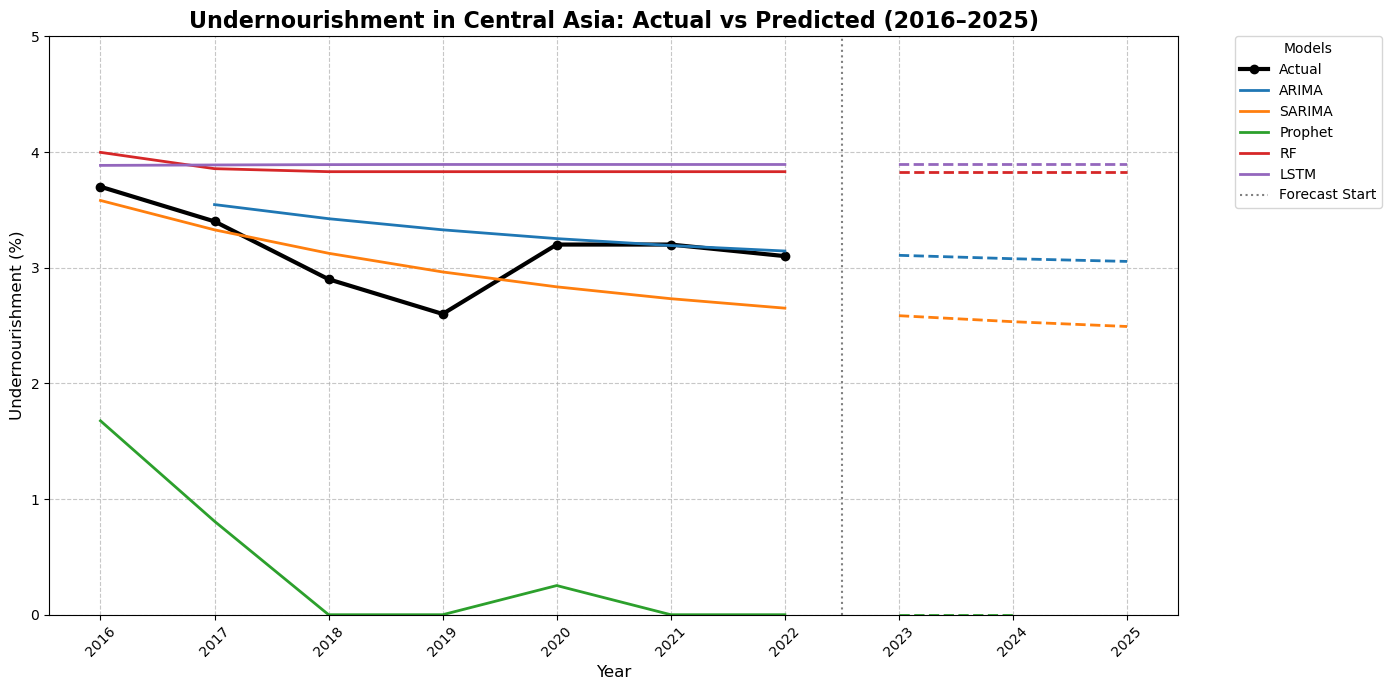

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("all_model_predictions_final.csv")

# Filter Central Asia and relevant years
central_asia_df = df[df["Country"] == "Central Asia"].copy()
central_asia_df["Actual"] = pd.to_numeric(central_asia_df["Actual"], errors="coerce")
central_asia_df = central_asia_df[central_asia_df["Year"].between(2016, 2025)]

# Simplified color map
color_map = {
   "ARIMA": "#1f77b4",      # Blue
   "SARIMA": "#ff7f0e",     # Orange
   "Prophet": "#2ca02c",    # Green
   "RF": "#d62728",         # Red
   "LSTM": "#9467bd"        # Purple
}

# Improved plot setup
plt.figure(figsize=(14, 7))

# Plot actuals (solid black, up to 2022)
actual = central_asia_df[central_asia_df["Year"] <= 2022]
plt.plot(actual["Year"], actual["Actual"], label="Actual", color="black", linewidth=3, marker='o')

# Plot each model with simplified styling
for model in color_map:
   model_df = central_asia_df[["Year", model]].dropna()
   eval_part = model_df[model_df["Year"] <= 2022]
   forecast_part = model_df[model_df["Year"] > 2022]
   
   # Evaluation part (solid line)
   if not eval_part.empty:
       plt.plot(eval_part["Year"], eval_part[model], 
                color=color_map[model], 
                linewidth=2, 
                label=model)
   
   # Forecast part (dashed line)
   if not forecast_part.empty:
       plt.plot(forecast_part["Year"], forecast_part[model], 
                color=color_map[model], 
                linestyle='--', 
                linewidth=2)

# Vertical line to separate evaluation and forecast
plt.axvline(2022.5, color="gray", linestyle=":", label='Forecast Start')

# Styling
plt.title("Undernourishment in Central Asia: Actual vs Predicted (2016–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Undernourishment (%)", fontsize=12)
plt.xticks(range(2016, 2026), rotation=45)
plt.ylim(0, 5)  # Tighter y-axis to focus on data range
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(title='Models', title_fontsize=10, loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

# Adjust layout to prevent cutting off labels
plt.tight_layout()
plt.show()

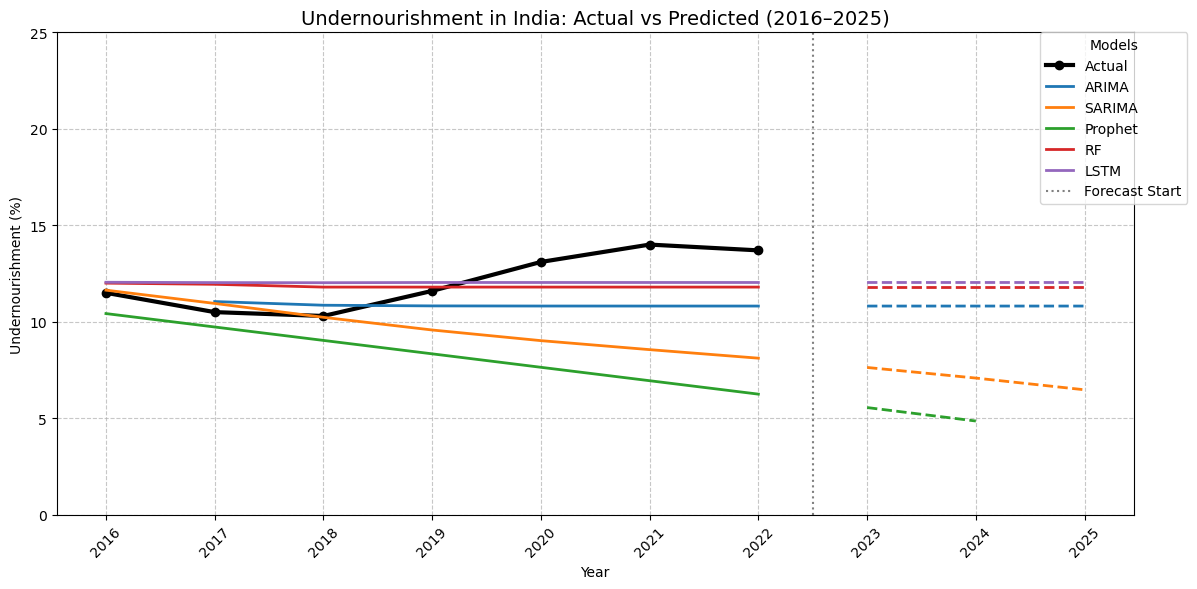

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("all_model_predictions_final.csv")

# Clip Prophet predictions
df["Prophet"] = pd.to_numeric(df["Prophet"], errors="coerce").clip(lower=0)

# Filter India and relevant years
india_df = df[df["Country"] == "India"].copy()
india_df["Actual"] = pd.to_numeric(india_df["Actual"], errors="coerce")
india_df = india_df[india_df["Year"].between(2016, 2025)]

# Consistent color map
color_map = {
   "ARIMA": "#1f77b4",      # Blue
   "SARIMA": "#ff7f0e",     # Orange
   "Prophet": "#2ca02c",    # Green
   "RF": "#d62728",         # Red
   "LSTM": "#9467bd"        # Purple
}

# Improved plot setup
plt.figure(figsize=(12, 6))

# Plot actuals (solid black, up to 2022)
actual = india_df[india_df["Year"] <= 2022]
plt.plot(actual["Year"], actual["Actual"], label="Actual", color="black", linewidth=3, marker='o')

# Plot each model with simplified styling
for model in color_map:
   model_df = india_df[["Year", model]].dropna()
   eval_part = model_df[model_df["Year"] <= 2022]
   forecast_part = model_df[model_df["Year"] > 2022]
   
   # Evaluation part (solid line)
   if not eval_part.empty:
       plt.plot(eval_part["Year"], eval_part[model], 
                color=color_map[model], 
                linewidth=2, 
                label=model)
   
   # Forecast part (dashed line)
   if not forecast_part.empty:
       plt.plot(forecast_part["Year"], forecast_part[model], 
                color=color_map[model], 
                linestyle='--', 
                linewidth=2)

# Vertical line to separate evaluation and forecast
plt.axvline(2022.5, color="gray", linestyle=":", label='Forecast Start')

# Enhanced styling
plt.title("Undernourishment in India: Actual vs Predicted (2016–2025)", fontsize=14)
plt.xlabel("Year", fontsize=10)
plt.ylabel("Undernourishment (%)", fontsize=10)
plt.xticks(range(2016, 2026), rotation=45)
plt.ylim(0, 25)  # Adjusted to accommodate India's higher values
plt.grid(True, linestyle='--', alpha=0.7)

# Simplified legend
plt.legend(title='Models', loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

plt.show()

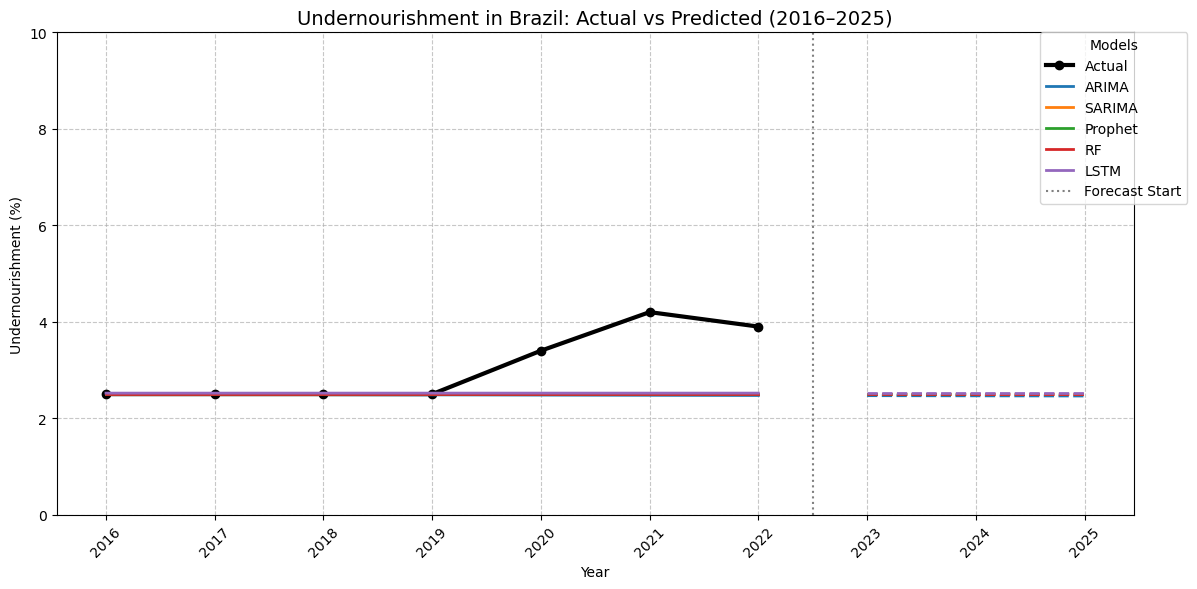

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("all_model_predictions_final.csv")

# Clip Prophet predictions
df["Prophet"] = pd.to_numeric(df["Prophet"], errors="coerce").clip(lower=0)

# Filter Brazil and relevant years
brazil_df = df[df["Country"] == "Brazil"].copy()
brazil_df["Actual"] = pd.to_numeric(brazil_df["Actual"], errors="coerce")
brazil_df = brazil_df[brazil_df["Year"].between(2016, 2025)]

# Consistent color map
color_map = {
    "ARIMA": "#1f77b4",      # Blue
    "SARIMA": "#ff7f0e",     # Orange
    "Prophet": "#2ca02c",    # Green
    "RF": "#d62728",         # Red
    "LSTM": "#9467bd"        # Purple
}

# Improved plot setup
plt.figure(figsize=(12, 6))

# Plot actuals (solid black, up to 2022)
actual = brazil_df[brazil_df["Year"] <= 2022]
plt.plot(actual["Year"], actual["Actual"], label="Actual", color="black", linewidth=3, marker='o')

# Plot each model with simplified styling
for model in color_map:
    model_df = brazil_df[["Year", model]].dropna()
    eval_part = model_df[model_df["Year"] <= 2022]
    forecast_part = model_df[model_df["Year"] > 2022]
    
    # Evaluation part (solid line)
    if not eval_part.empty:
        plt.plot(eval_part["Year"], eval_part[model], 
                 color=color_map[model], 
                 linewidth=2, 
                 label=model)
    
    # Forecast part (dashed line)
    if not forecast_part.empty:
        plt.plot(forecast_part["Year"], forecast_part[model], 
                 color=color_map[model], 
                 linestyle='--', 
                 linewidth=2)

# Vertical line to separate evaluation and forecast
plt.axvline(2022.5, color="gray", linestyle=":", label='Forecast Start')

# Enhanced styling
plt.title("Undernourishment in Brazil: Actual vs Predicted (2016–2025)", fontsize=14)
plt.xlabel("Year", fontsize=10)
plt.ylabel("Undernourishment (%)", fontsize=10)
plt.xticks(range(2016, 2026), rotation=45)
plt.ylim(0, 10)  # Adjusted to Brazil's lower undernourishment range
plt.grid(True, linestyle='--', alpha=0.7)

# Simplified legend
plt.legend(title='Models', loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

plt.show()